In [3]:

import numpy as np


class FastVector:
    """
    Minimal wrapper for fastvector embeddings.
    ```
    Usage:
        $ model = FastVector(vector_file='/path/to/wiki.en.vec')
        $ 'apple' in model
        > TRUE
        $ model['apple'].shape
        > (300,)
    ```
    """

    def __init__(self, vector_file='', transform=None):
        """Read in word vectors in fasttext format"""
        self.word2id = {}

        # Captures word order, for export() and translate methods
        self.id2word = []

        print('reading word vectors from %s' % vector_file)
        with open(vector_file, 'r') as f:
            (self.n_words, self.n_dim) = \
                (int(x) for x in f.readline().rstrip('\n').split(' '))
            self.embed = np.zeros((self.n_words, self.n_dim))
            for i, line in enumerate(f):
                elems = line.rstrip('\n').split(' ')
                self.word2id[elems[0]] = i
                self.embed[i] = elems[1:self.n_dim+1]
                self.id2word.append(elems[0])
        
        # Used in translate_inverted_softmax()
        self.softmax_denominators = None
        
        if transform is not None:
            print('Applying transformation to embedding')
            self.apply_transform(transform)

    def apply_transform(self, transform):
        """
        Apply the given transformation to the vector space

        Right-multiplies given transform with embeddings E:
            E = E * transform

        Transform can either be a string with a filename to a
        text file containing a ndarray (compat. with np.loadtxt)
        or a numpy ndarray.
        """
        transmat = np.loadtxt(transform) if isinstance(transform, str) else transform
        self.embed = np.matmul(self.embed, transmat)

    def export(self, outpath):
        """
        Transforming a large matrix of WordVectors is expensive. 
        This method lets you write the transformed matrix back to a file for future use
        :param The path to the output file to be written 
        """
        fout = open(outpath, "w")

        # Header takes the guesswork out of loading by recording how many lines, vector dims
        fout.write(str(self.n_words) + " " + str(self.n_dim) + "\n")
        for token in self.id2word:
            vector_components = ["%.6f" % number for number in self[token]]
            vector_as_string = " ".join(vector_components)

            out_line = token + " " + vector_as_string + "\n"
            fout.write(out_line)

        fout.close()

    def translate_nearest_neighbour(self, source_vector):
        """Obtain translation of source_vector using nearest neighbour retrieval"""
        similarity_vector = np.matmul(FastVector.normalised(self.embed), source_vector)
        target_id = np.argmax(similarity_vector)
        return self.id2word[target_id]

    def translate_inverted_softmax(self, source_vector, source_space, nsamples,
                                   beta=10., batch_size=100, recalculate=True):
        """
        Obtain translation of source_vector using sampled inverted softmax retrieval
        with inverse temperature beta.

        nsamples vectors are drawn from source_space in batches of batch_size
        to calculate the inverted softmax denominators.
        Denominators from previous call are reused if recalculate=False. This saves
        time if multiple words are translated from the same source language.
        """
        embed_normalised = FastVector.normalised(self.embed)
        # calculate contributions to softmax denominators in batches
        # to save memory
        if self.softmax_denominators is None or recalculate is True:
            self.softmax_denominators = np.zeros(self.embed.shape[0])
            while nsamples > 0:
                # get batch of randomly sampled vectors from source space
                sample_vectors = source_space.get_samples(min(nsamples, batch_size))
                # calculate cosine similarities between sampled vectors and
                # all vectors in the target space
                sample_similarities = \
                    np.matmul(embed_normalised,
                              FastVector.normalised(sample_vectors).transpose())
                # accumulate contribution to denominators
                self.softmax_denominators \
                    += np.sum(np.exp(beta * sample_similarities), axis=1)
                nsamples -= batch_size
        # cosine similarities between source_vector and all target vectors
        similarity_vector = np.matmul(embed_normalised,
                                      source_vector/np.linalg.norm(source_vector))
        # exponentiate and normalise with denominators to obtain inverted softmax
        softmax_scores = np.exp(beta * similarity_vector) / \
                         self.softmax_denominators
        # pick highest score as translation
        target_id = np.argmax(softmax_scores)
        return self.id2word[target_id]

    def get_samples(self, nsamples):
        """Return a matrix of nsamples randomly sampled vectors from embed"""
        sample_ids = np.random.choice(self.embed.shape[0], nsamples, replace=False)
        return self.embed[sample_ids]

    @classmethod
    def normalised(cls, mat, axis=-1, order=2):
        """Utility function to normalise the rows of a numpy array."""
        norm = np.linalg.norm(
            mat, axis=axis, ord=order, keepdims=True)
        norm[norm == 0] = 1
        return mat / norm
    
    @classmethod
    def cosine_similarity(cls, vec_a, vec_b):
        """Compute cosine similarity between vec_a and vec_b"""
        return np.dot(vec_a, vec_b) / \
            (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))

    def __contains__(self, key):
        return key in self.word2id

    def __getitem__(self, key):
        return self.embed[self.word2id[key]]


In [4]:
import numpy as np
import gensim
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Normalization function for word vectors
def normalize(a, axis=-1, order=2):
    l2 = np.atleast_1d(np.linalg.norm(a, order, axis))
    l2[l2 == 0] = 1
    return a / np.expand_dims(l2, axis)

# Load FastText models for English and Hindi
en_model = gensim.models.KeyedVectors.load_word2vec_format('cc.en.300.vec\cc.en.300.vec')
hi_model = gensim.models.KeyedVectors.load_word2vec_format('cc.hi.300.vec\cc.hi.300.vec')

In [5]:
bilingual_lexicon = [] 
for line in open('english-hindi-full-bilingual-lexicon.txt', encoding='utf-8'):
    en_word, hi_word = line.strip().split('\t')
    bilingual_lexicon.append((en_word, hi_word))

# Create training matrices based on bilingual lexicon
def make_training_matrices(lexicon, en_model, hi_model):
    en_matrix, hi_matrix = [], []
    for en_word, hi_word in lexicon:
        if en_word in en_model and hi_word in hi_model:
            en_matrix.append(en_model[en_word])
            hi_matrix.append(hi_model[hi_word])
    return np.array(en_matrix), np.array(hi_matrix)

# Learning the transformation matrix using Procrustes method
def learn_transformation(X_en, X_hi, normalize_vectors=True):
    if normalize_vectors:
        X_en = normalize(X_en)
        X_hi = normalize(X_hi)
    # Compute SVD and learn orthogonal matrix
    product = np.dot(X_en.T, X_hi)
    U, _, V = np.linalg.svd(product)
    W = np.dot(U, V)
    return W

# Generate embeddings and learn transformation
X_en, X_hi = make_training_matrices(bilingual_lexicon, en_model, hi_model)
W = learn_transformation(X_en, X_hi)

# Align the source embeddings (English) using the learned matrix
def align_embeddings(embeddings, W):
    return np.dot(embeddings, W)

aligned_embeddings = align_embeddings(X_en, W)



In [6]:
def find_nearest_hindi_word(aligned_embedding, hi_model):
  """Finds the nearest Hindi word to the given aligned embedding.

  Args:
    aligned_embedding: The aligned English word embedding.
    hi_model: The Hindi FastText model.

  Returns:
    The nearest Hindi word and its cosine similarity to the aligned embedding.
  """
  max_similarity = -1
  nearest_word = None
  for word in hi_model.key_to_index:
    similarity = FastVector.cosine_similarity(aligned_embedding, hi_model[word])
    if similarity > max_similarity:
      max_similarity = similarity
      nearest_word = word
  return nearest_word, max_similarity

# Example usage (assuming aligned_money is already calculated)


In [11]:
en_word = "weight"
aligned_money = align_embeddings(en_model[en_word].reshape(1,-1), W)
nearest_hindi_word, similarity = find_nearest_hindi_word(aligned_money[0], hi_model)

print(f"Nearest Hindi word to aligned '{en_word}': {nearest_hindi_word} (similarity: {similarity:.4f})")

Nearest Hindi word to aligned 'weight': वजन (similarity: 0.6800)


In [8]:
## evaluate precision@1, precision@2, precision@5, precision@10
def evaluate_precision(lexicon, en_model, hi_model, W, k=10):
    num_matches = 0
    for en_word, hi_word in lexicon:
        if en_word in en_model and hi_word in hi_model:
            aligned_en = align_embeddings(en_model[en_word].reshape(1, -1), W)
            nearest_hindi_word, _ = find_nearest_hindi_word(aligned_en[0], hi_model)
            if nearest_hindi_word == hi_word:
                num_matches += 1
    return num_matches / len(lexicon)

In [10]:

precision_1 = evaluate_precision(bilingual_lexicon[:10], en_model, hi_model, W, k=1)
print(f"Precision@1: {precision_1:.4f}")
precision_2 = evaluate_precision(bilingual_lexicon[:10], en_model, hi_model, W, k=2)
print(f"Precision@2: {precision_2:.4f}")
precision_5 = evaluate_precision(bilingual_lexicon[:10], en_model, hi_model, W, k=5)
print(f"Precision@5: {precision_5:.4f}")
precision_10 = evaluate_precision(bilingual_lexicon[:10], en_model, hi_model, W, k=10)
print(f"Precision@10: {precision_10:.4f}")

Precision@1: 0.1000
Precision@2: 0.1000
Precision@5: 0.1000
Precision@10: 0.1000


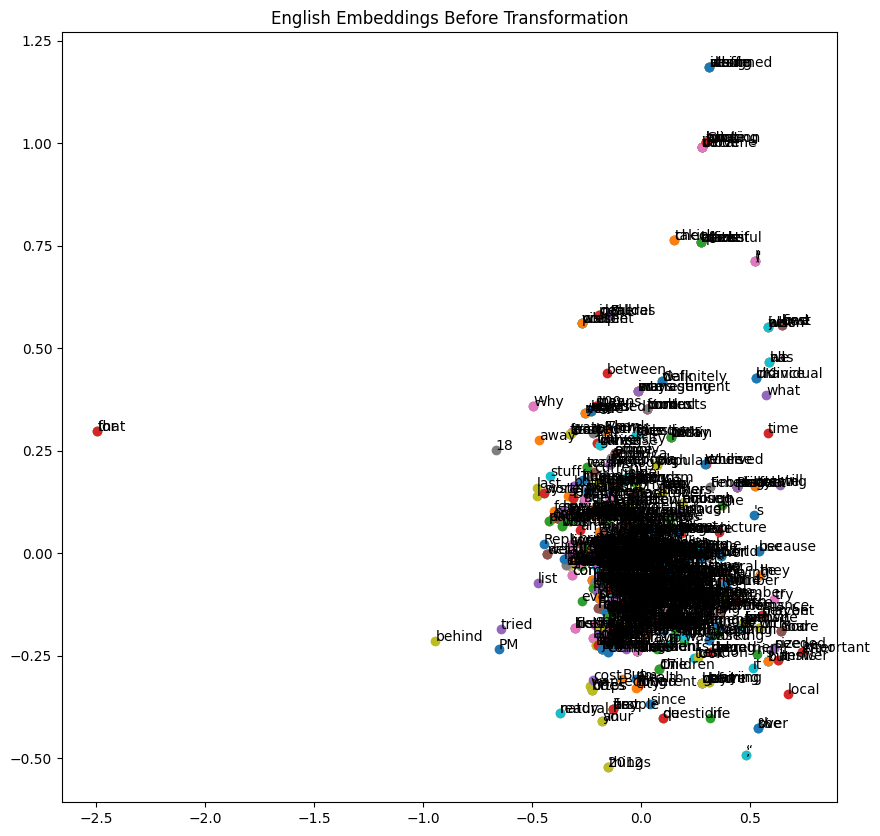

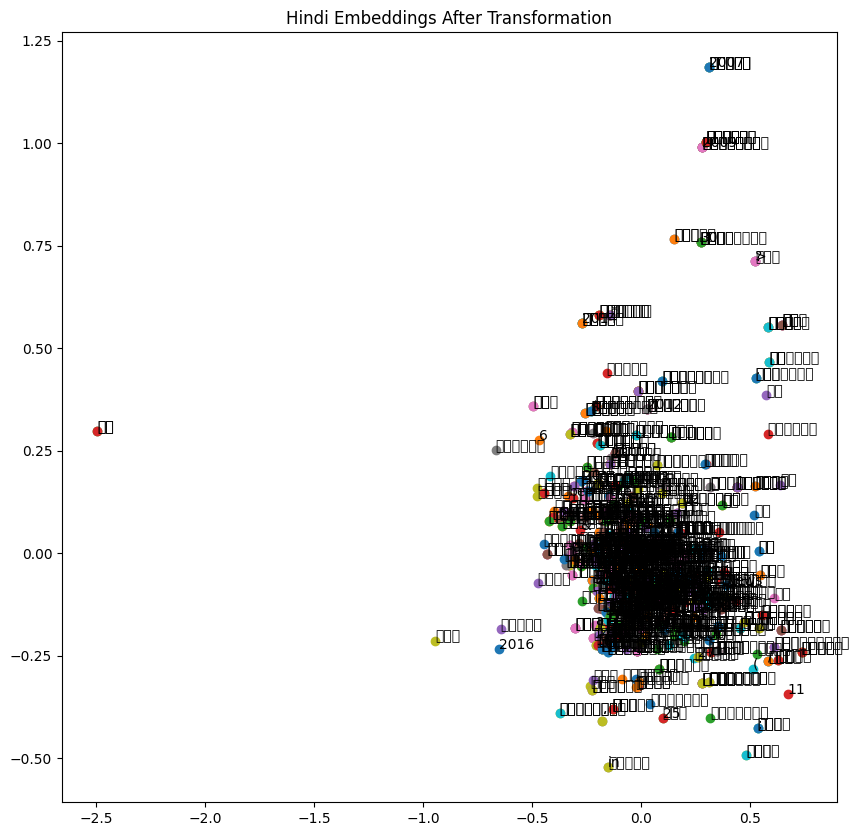

In [21]:
# visualize embeddings before transformation and after transformation

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings 
warnings.filterwarnings('ignore')

def plot_embeddings(embeddings, model, title):
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(embeddings)
    plt.figure(figsize=(10, 10))
    
    num_points = min(len(model.index_to_key), pca_result.shape[0])
    for i in range(num_points):
        word = model.index_to_key[i]
        plt.scatter(pca_result[i, 0], pca_result[i, 1])
        plt.text(pca_result[i, 0], pca_result[i, 1], word)
    
    plt.title(title)
    plt.show()

plot_embeddings(X_en[:1000], en_model, "English Embeddings Before Transformation")
plot_embeddings(aligned_embeddings[:1000], hi_model, "Hindi Embeddings After Transformation")

In [22]:
en_model.get_words()

AttributeError: 'KeyedVectors' object has no attribute 'get_words'